<div style="background:#12355b;color:white;padding:16px 36px;border-radius:6px;">
<h1 style="margin:0;">Exploratory Data Analysis</h1>
<p style="margin:6px 0 0;">Vietnam Car Sales Dataset Analysis</p>
</div>

## **Table of contents**

* [0. Setup & Imports](#0-setup-imports)
* [1. Load Processed Data](#1-load-processed-data)
* [2. Data Quality & Consistency Check](#2-data-quality--consistency-check)
* [3. Univariate Analysis](#3-univariate-analysis)
    * [3.1. Numerical Variables Distribution](#31-numerical-variables-distribution)
    * [3.2. Categorical Variables Distribution](#32-categorical-variables-distribution)
* [4. Bivariate & Multivariate Analysis](#4-bivariate--multivariate-analysis)
    * [4.1. Price vs Key Factors](#41-price-vs-key-factors)
    * [4.2. Categorical Relationships](#42-categorical-relationships)
    * [4.3. Correlation Matrix](#43-correlation-matrix)
* [5. Advanced Analysis & Insights](#5-advanced-analysis--insights)
    * [5.1. Market Segmentation (Clustering Concept)](#51-market-segmentation)
    * [5.2. Anomaly Detection (Outliers)](#52-anomaly-detection)
* [6. Key Findings & Conclusion](#6-key-findings--strategic-insights)

<a id="0-setup-imports"></a>
## **0. Setup & Imports**

**Mục tiêu:** Thiết lập môi trường làm việc, nạp các thư viện cần thiết cho phân tích số liệu và trực quan hóa dữ liệu, đồng thời cấu hình các thông số đồ họa đồng bộ để đảm bảo chất lượng hình ảnh hiển thị.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Set plotting configurations
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'axes.grid'        : False,
})
sns.set_theme(style='white')

# Define global visualization constants
PRIMARY_COLOR = '#1f77b4'
ACCENT_COLOR = '#e94560'
MUTED_COLOR = '#7f7f7f'

# Directory path configuration
PROCESSED_DIR = Path('../data/processed')

print('Môi trường hệ thống đã được khởi tạo thành công.')

Môi trường hệ thống đã được khởi tạo thành công.


<a id="1-load-processed-data"></a>
## **1. Load Processed Data**

**Mục tiêu:** Nạp dữ liệu chính từ bảng fact và các bảng chiều đã được chuẩn hóa ở bước tiền xử lý để phục vụ cho các phân tích khám phá tiếp theo.

In [2]:
# Load main dataset and dimension tables
try:
    fact_df = pd.read_csv(PROCESSED_DIR / 'fact_car_listings.csv', encoding='utf-8-sig')
    dim_brand = pd.read_csv(PROCESSED_DIR / 'dim_brand.csv', encoding='utf-8-sig')
    dim_body_type = pd.read_csv(PROCESSED_DIR / 'dim_body_type.csv', encoding='utf-8-sig')
    dim_condition = pd.read_csv(PROCESSED_DIR / 'dim_condition.csv', encoding='utf-8-sig')
    dim_origin = pd.read_csv(PROCESSED_DIR / 'dim_origin.csv', encoding='utf-8-sig')
    dim_transmission = pd.read_csv(PROCESSED_DIR / 'dim_transmission.csv', encoding='utf-8-sig')
    dim_drivetrain = pd.read_csv(PROCESSED_DIR / 'dim_drivetrain.csv', encoding='utf-8-sig')
    dim_fuel_type = pd.read_csv(PROCESSED_DIR / 'dim_fuel_type.csv', encoding='utf-8-sig')

    # Merge fact table with key dimensions for easier analysis
    df = fact_df.merge(dim_brand, on='id_hãng', how='left') \
                .merge(dim_body_type, on='id_dòng_xe', how='left') \
                .merge(dim_condition, on='id_tình_trạng', how='left') \
                .merge(dim_origin, on='id_xuất_xứ', how='left') \
                .merge(dim_transmission, on='id_hộp_số', how='left') \
                .merge(dim_drivetrain, on='id_dẫn_động', how='left') \
                .merge(dim_fuel_type, on='id_loại_nhiên_liệu', how='left')

    print('Tải các tập dữ liệu đã xử lý thành công.')
    print(f'Số lượng bản ghi của bảng fact: {len(df):,}')
    display(df.head())
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")

Tải các tập dữ liệu đã xử lý thành công.
Số lượng bản ghi của bảng fact: 33,848


,id_tin_đăng,URL,Mã tin,Tên xe,Mô tả,Năm sản xuất,Giá (triệu VND),Số Km đã đi sạch,Dung tích động cơ (lít),Tiêu thụ nhiên liệu sạch,...,id_loại_nhiên_liệu,id_hãng,id_phân_khúc,Hãng,Dòng xe,Tình trạng,Xuất xứ,Hộp số,Dẫn động,Loại nhiên liệu
0,1,https://bonbanh.com/xe-suzuki-super_carry_truc...,17042,Xe Suzuki Super Carry Truck 1.0 MT 2022,Super Carry Truck 5 tạ thùng lửng được trang b...,2022.0,249.0,0.0,1.0,NaN,...,4,78,505,Suzuki,Truck,Xe mới,Lắp ráp trong nước,Số tay,RFD - Dẫn động cầu sau,Xăng
1,2,https://bonbanh.com/xe-toyota-land_cruiser-3.5...,53794,Xe Toyota Land Cruiser 3.5 V6 2022,"Toyota LANDCRUISER 300 mới, nhập khẩu Nhật Bản...",2022.0,4286.0,0.0,3.4,10.0,...,4,83,545,Toyota,SUV,Xe mới,Nhập khẩu,Số tự động,AWD - 4 bánh toàn thời gian,Xăng
2,3,https://bonbanh.com/xe-toyota-innova-g-2.0-at-...,73954,Xe Toyota Innova G 2.0 AT 2023,**Hỗ trợ lệ phí trước bạ trị giá 15 triệu đồng...,2023.0,885.0,0.0,2.0,NaN,...,4,83,543,Toyota,Crossover,Xe mới,Lắp ráp trong nước,Số tự động,RFD - Dẫn động cầu sau,Xăng
3,4,https://bonbanh.com/xe-toyota-corolla_cross-1....,74150,Xe Toyota Corolla Cross 1.8G 2023,"- 2 màu nội thất: đen, đỏ nâu- Xe có sẵn giao ...",2023.0,754.0,0.0,1.8,NaN,...,4,83,534,Toyota,SUV,Xe mới,Nhập khẩu,Số tự động,FWD - Dẫn động cầu trước,Xăng
4,5,https://bonbanh.com/xe-toyota-innova-g-2.0-at-...,87573,Xe Toyota Innova G 2.0 AT 2022,Toyota Innova G mới 100%Trang bị động cơ 2.0. ...,2022.0,850.0,0.0,2.0,NaN,...,4,83,543,Toyota,Crossover,Xe mới,Lắp ráp trong nước,Số tự động,RFD - Dẫn động cầu sau,Xăng


**Nhận xét:**

Dữ liệu đã được gộp thành công từ bảng fact và các bảng. Dataframe `df` hiện tại chứa đầy đủ các thông tin cần thiết phục vụ cho quá trình EDA với tổng cộng 33.848 bản ghi.

<a id="2-data-quality--consistency-check"></a>
## **2. Data Quality & Consistency Check**

**Mục tiêu:** Kiểm tra lại chất lượng dữ liệu sau tiền xử lý, đảm bảo không có các giá trị bất thường về thời gian, giá cả, và đánh giá tỷ lệ missing values (nếu có).

In [3]:
# Check basic info and missing values
print("Thông tin tập dữ liệu:")
df.info()

print("\nTỷ lệ phần trăm giá trị thiếu:")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Check consistency for continuous variables
print("\nThống kê mô tả cho các cột số (cột định lượng):")
display(df[['Giá (triệu VND)', 'Năm sản xuất', 'Số Km đã đi sạch', 'Dung tích động cơ (lít)']].describe())

# Check for illogical data
illogical_year = df[(df['Năm sản xuất'] < 1990) | (df['Năm sản xuất'] > 2024)]
print(f"\nSố lượng bản ghi có năm sản xuất bất hợp lý (<1990 hoặc >2024): {len(illogical_year)}")

illogical_price = df[df['Giá (triệu VND)'] <= 0]
print(f"Số lượng bản ghi có giá bất hợp lý (<= 0): {len(illogical_price)}")

illogical_mileage = df[(df['Tình trạng'] == 'Xe mới') & (df['Số Km đã đi sạch'] > 1000)]
print(f"Số lượng bản ghi 'Xe mới' có số Km đã đi lớn (> 1000km): {len(illogical_mileage)}")

Thông tin tập dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33848 entries, 0 to 33847
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_tin_đăng               33848 non-null  int64  
 1   URL                       33848 non-null  object 
 2   Mã tin                    33848 non-null  int64  
 3   Tên xe                    33848 non-null  object 
 4   Mô tả                     33848 non-null  object 
 5   Năm sản xuất              33816 non-null  float64
 6   Giá (triệu VND)           33848 non-null  float64
 7   Số Km đã đi sạch          32792 non-null  float64
 8   Dung tích động cơ (lít)   32013 non-null  float64
 9   Tiêu thụ nhiên liệu sạch  11355 non-null  float64
 10  Số cửa sạch               33747 non-null  float64
 11  Số chỗ ngồi sạch          33764 non-null  float64
 12  id_xuất_xứ                33848 non-null  int64  
 13  id_tình_trạng             33848 non-nu

,Giá (triệu VND),Năm sản xuất,Số Km đã đi sạch,Dung tích động cơ (lít)
count,33848.000000,33816.000000,32792.000000,32013.000000
mean,1201.576489,2017.998876,35802.524579,2.035322
std,2046.513114,5.493243,47187.399725,0.805623
min,18.000000,1990.000000,0.000000,0.100000
25%,425.000000,2015.000000,0.000000,1.500000
50%,638.000000,2019.000000,20000.000000,2.000000
75%,1087.000000,2022.000000,58000.000000,2.300000
max,54000.000000,2025.000000,500000.000000,18.000000



Số lượng bản ghi có năm sản xuất bất hợp lý (<1990 hoặc >2024): 1597
Số lượng bản ghi có giá bất hợp lý (<= 0): 0
Số lượng bản ghi 'Xe mới' có số Km đã đi lớn (> 1000km): 3


**Nhận xét:**

Việc kiểm tra cho thấy dữ liệu nhìn chung đã sạch sau bước tiền xử lý. Cột `Tiêu thụ nhiên liệu sạch` có tỷ lệ missing data cao nhất (66.45%), tiếp theo là `Dung tích động cơ (lít)` (5.42%) và `Số Km đã đi sạch` (3.12%). Phát hiện 1597 bản ghi có năm sản xuất bất thường (<1990 hoặc >2024) và 3 trường hợp 'Xe mới' nhưng có số Km > 1000km. Các giá trị này cần được cân nhắc làm sạch thêm hoặc loại bỏ để không ảnh hưởng đến mô hình dự đoán giá.

<a id="3-univariate-analysis"></a>
## **3. Univariate Analysis**

**Mục tiêu:** Khám phá đặc điểm phân phối của từng biến số độc lập, giúp có cái nhìn tổng quan về thị trường xe ô tô tại Việt Nam.

<a id="31-numerical-variables-distribution"></a>
### **3.1. Numerical Variables Distribution**

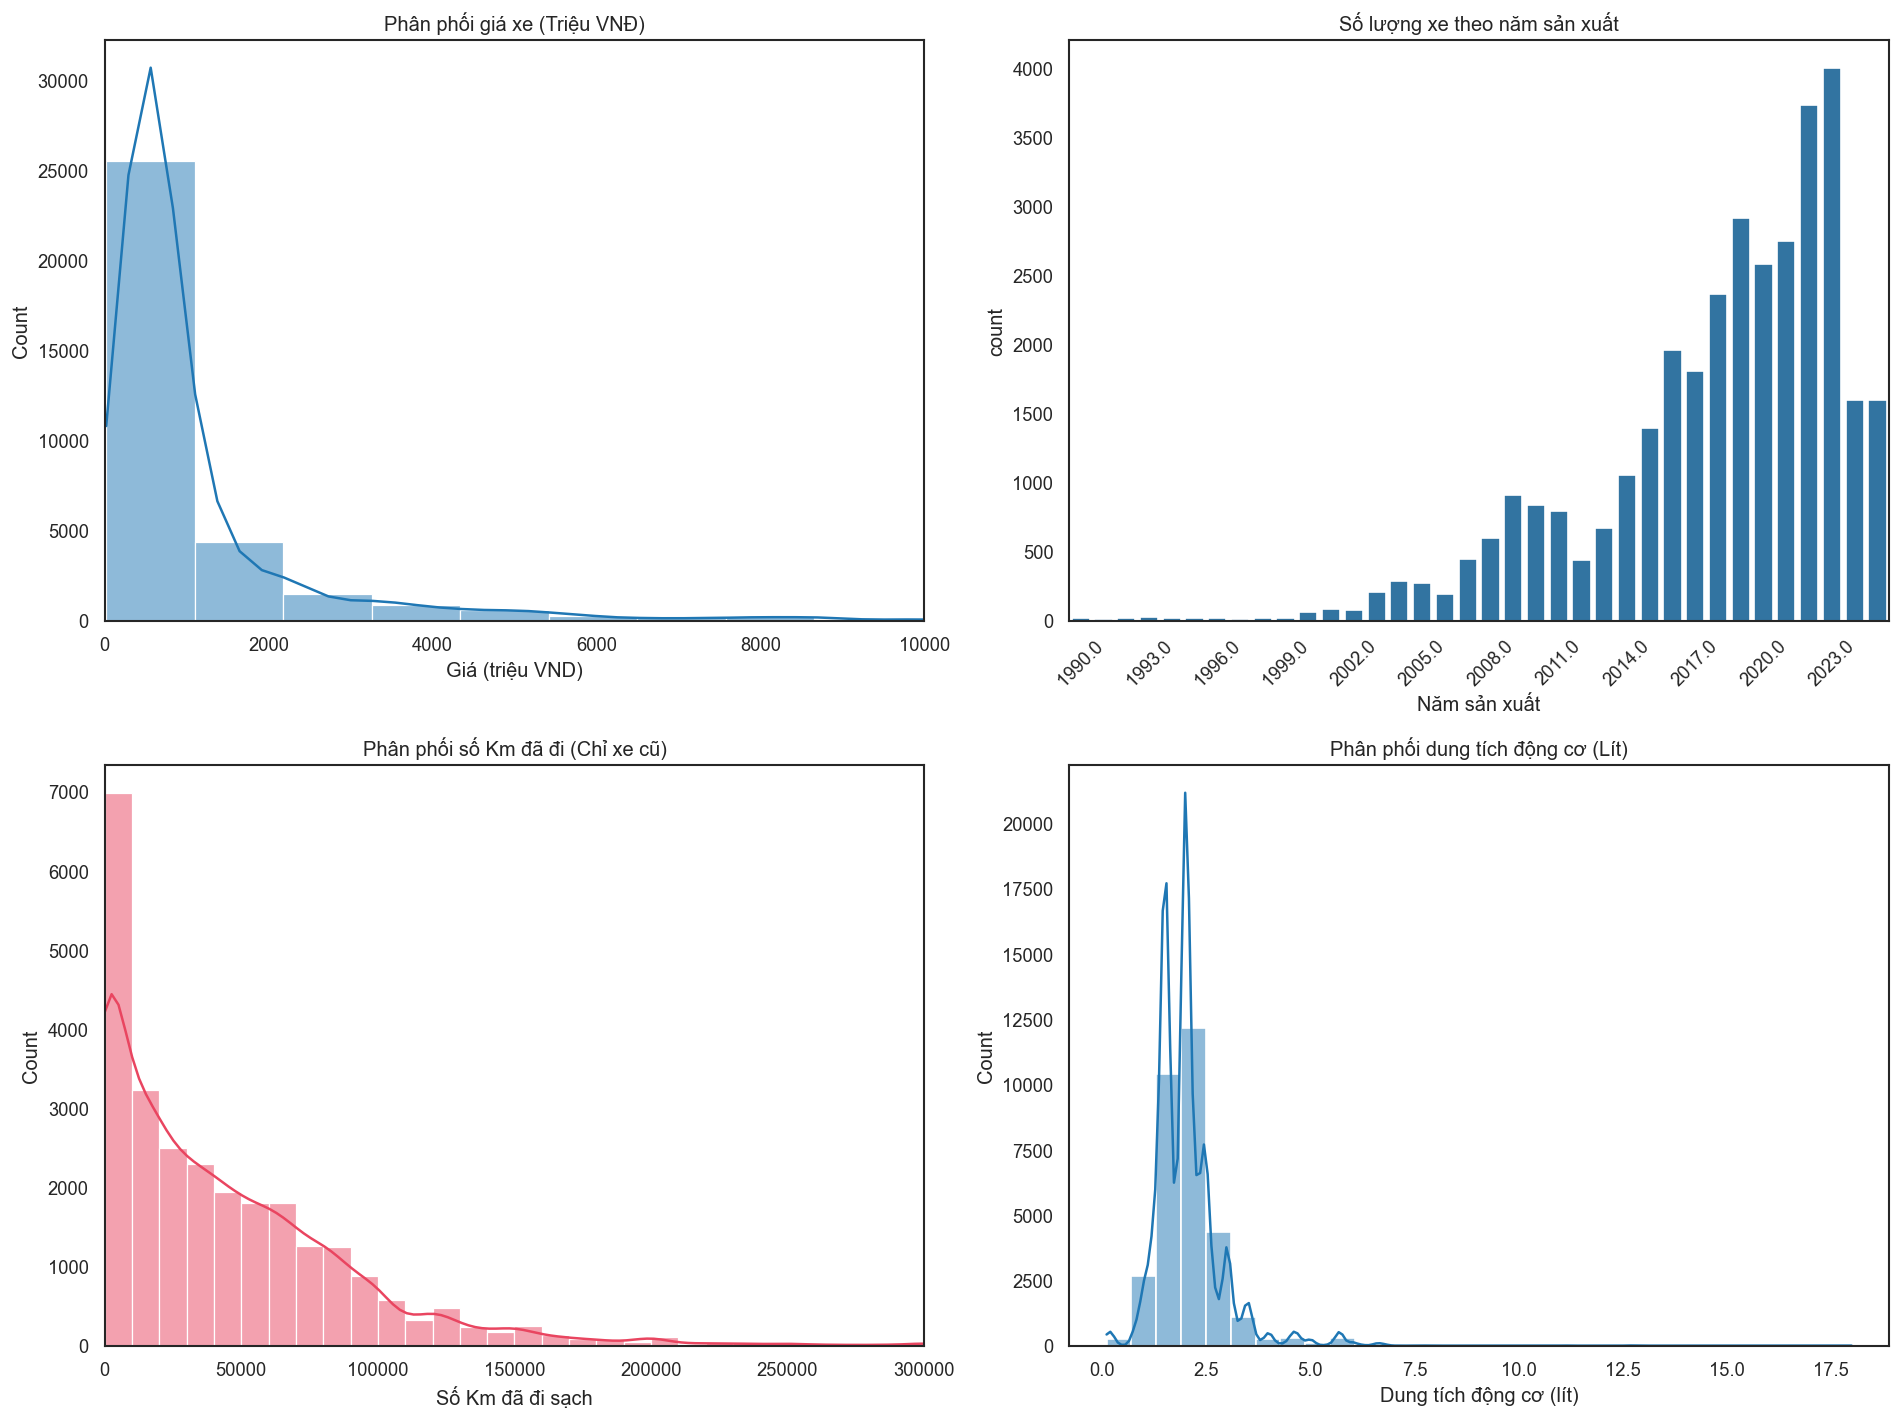

In [4]:
# Set up the figure for numerical distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Price Distribution (Log scale due to right skewness)
sns.histplot(df['Giá (triệu VND)'], bins=50, kde=True, ax=axes[0, 0], color=PRIMARY_COLOR)
axes[0, 0].set_title('Phân phối giá xe (Triệu VNĐ)')
axes[0, 0].set_xlim(0, 10000) # Limit to 10 billion for better view of majority

# 2. Manufacture Year
sns.countplot(data=df, x='Năm sản xuất', ax=axes[0, 1], color=PRIMARY_COLOR)
axes[0, 1].set_title('Số lượng xe theo năm sản xuất')
axes[0, 1].tick_params(axis='x', rotation=45)
# Show only every 3rd year for readability if there are too many
for index, label in enumerate(axes[0, 1].xaxis.get_ticklabels()):
    if index % 3 != 0:
        label.set_visible(False)

# 3. Mileage Distribution (For Used Cars)
used_cars = df[df['Tình trạng'] == 'Xe đã dùng']
sns.histplot(used_cars['Số Km đã đi sạch'], bins=50, kde=True, ax=axes[1, 0], color=ACCENT_COLOR)
axes[1, 0].set_title('Phân phối số Km đã đi (Chỉ xe cũ)')
axes[1, 0].set_xlim(0, 300000) # Limit to 300k km

# 4. Engine Capacity
sns.histplot(df['Dung tích động cơ (lít)'], bins=30, kde=True, ax=axes[1, 1], color=PRIMARY_COLOR)
axes[1, 1].set_title('Phân phối dung tích động cơ (Lít)')

plt.tight_layout()
plt.show()

**Nhận xét:**

- **Giá xe (Histogram):** Biểu đồ thể hiện rõ hình dáng phân phối rất lệch phải. Cột cao nhất tập trung khổng lồ ở dải phân khúc giá dưới 1,5 tỷ VNĐ, sau đó biểu đồ tạo thành một cái đuôi dài trải rộng đến 10 tỷ VNĐ dành cho các dòng xe sang trọng.

- **Năm sản xuất (Bar Chart):** Biểu đồ cột có xu hướng tăng dần và tạo đỉnh ở các năm gần đây. Hai cột cao nhất thuộc về năm 2023 (với hơn 4000 xe) và 2022 (hơn 3500 xe). Ngoài ra có thể thấy một lượng không nhỏ các xe được ghi nhận sản xuất năm 2024 và 2025.

- **Số Km đã đi (Histogram):** Áp dụng trên tập xe cũ, biểu đồ cho thấy dữ liệu phân bổ khá đều thành một khối ngang rộng ở dải từ 0 đến 100.000 km, với số lượng tin đăng xấp xỉ 6500-6700 xe cho mỗi khoảng (0-20k, 20k-50k, 50k-100k). Vượt qua mốc 100.000 km, cột biểu đồ giảm độ cao rõ rệt xuống dải dưới 1000 xe và kéo dài ra xa.

- **Dung tích động cơ (Histogram):** Có 2 đỉnh nổi bật hẳn lên trên biểu đồ, với đỉnh cao nhất nằm chính xác ở mốc 2.0L, và đỉnh thứ hai nằm ở mức 1.5L. Các mốc dung tích khác (như 2.5L, 1.6L) có số lượng thấp hơn hẳn tạo thành các cột nhỏ xen kẽ.

<a id="32-categorical-variables-distribution"></a>
### **3.2. Categorical Variables Distribution**

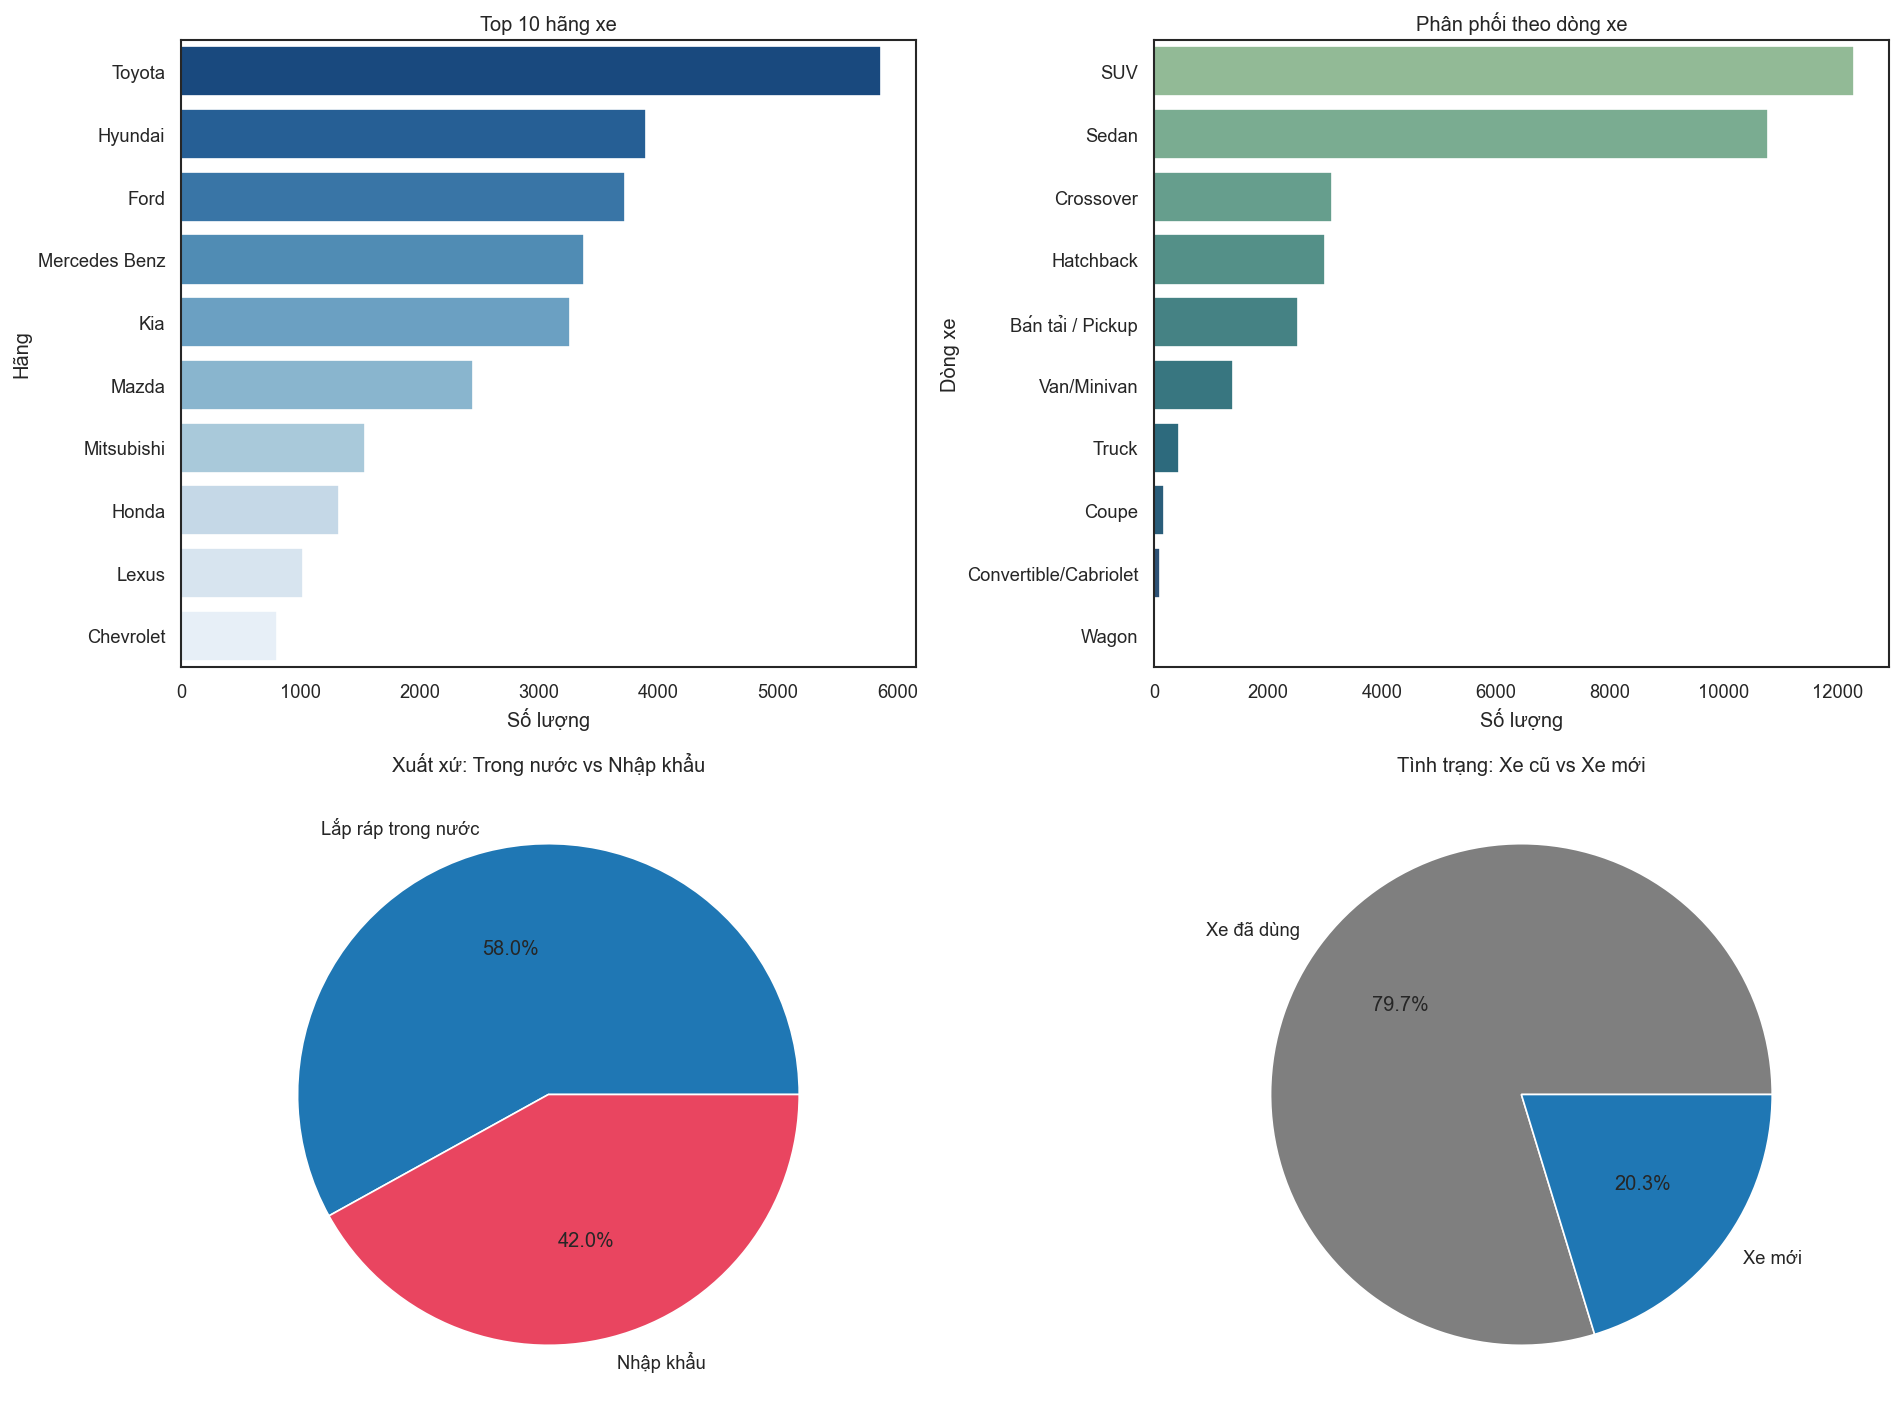

In [5]:
# Set up the figure for categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10 Brands
top_brands = df['Hãng'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Top 10 hãng xe')
axes[0, 0].set_xlabel('Số lượng')

# 2. Body Type
body_types = df['Dòng xe'].value_counts()
sns.barplot(x=body_types.values, y=body_types.index, ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Phân phối theo dòng xe')
axes[0, 1].set_xlabel('Số lượng')

# 3. Origin & Condition (Pie Charts)
origin_counts = df['Xuất xứ'].value_counts()
axes[1, 0].pie(origin_counts, labels=origin_counts.index, autopct='%1.1f%%', colors=[PRIMARY_COLOR, ACCENT_COLOR])
axes[1, 0].set_title('Xuất xứ: Trong nước vs Nhập khẩu')

condition_counts = df['Tình trạng'].value_counts()
axes[1, 1].pie(condition_counts, labels=condition_counts.index, autopct='%1.1f%%', colors=[MUTED_COLOR, PRIMARY_COLOR])
axes[1, 1].set_title('Tình trạng: Xe cũ vs Xe mới')

plt.tight_layout()
plt.show()

**Nhận xét:**

- **Thương hiệu:** Toyota, Hyundai, Ford, Mercedes-Benz, Kia là các hãng dẫn đầu về số lượng tin bán.

- **Dòng xe:** SUV và Sedan chiếm ưu thế áp đảo thị trường.

- **Xuất xứ & Tình trạng:** Hơn 50% là xe lắp ráp trong nước. Đa số (gần 80%) tin đăng là xe đã qua sử dụng.

<a id="4-bivariate--multivariate-analysis"></a>
## **4. Bivariate & Multivariate Analysis**

**Mục tiêu:** Đánh giá sự tương quan giữa giá xe và các đặc tính khác, đồng thời khám phá mối liên hệ giữa các biến phân loại. Đây là tiền đề cho phần AI Insights trong PowerBI.

<a id="41-price-vs-key-factors"></a>
### **4.1. Price vs Key Factors**

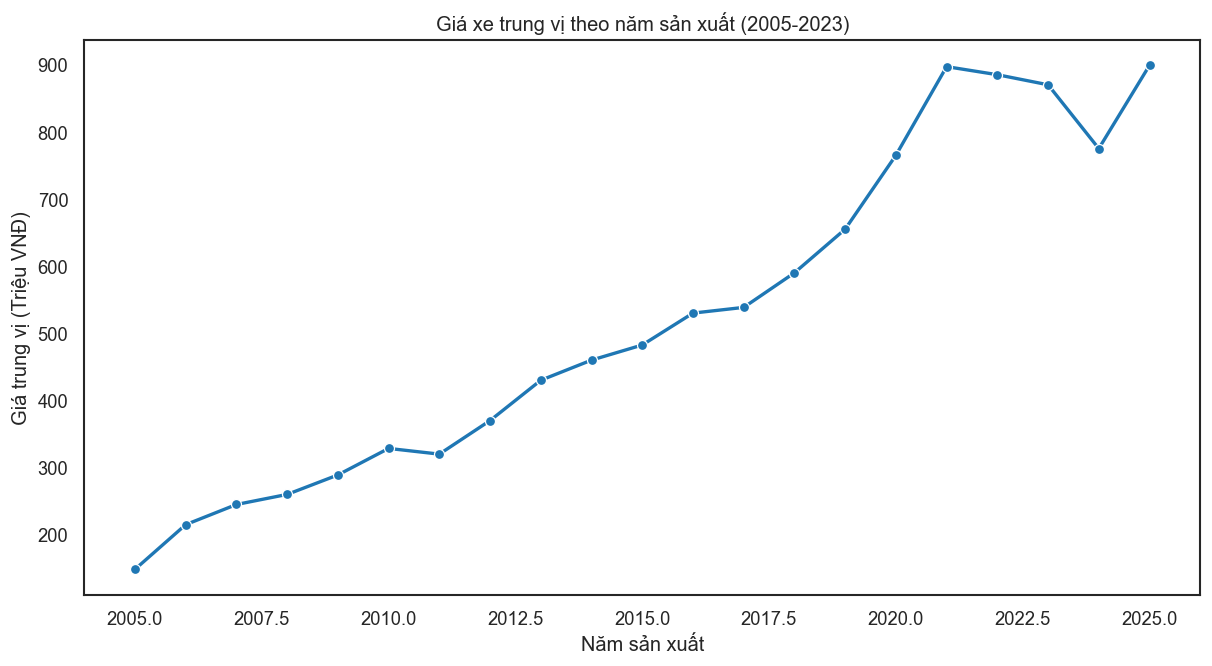

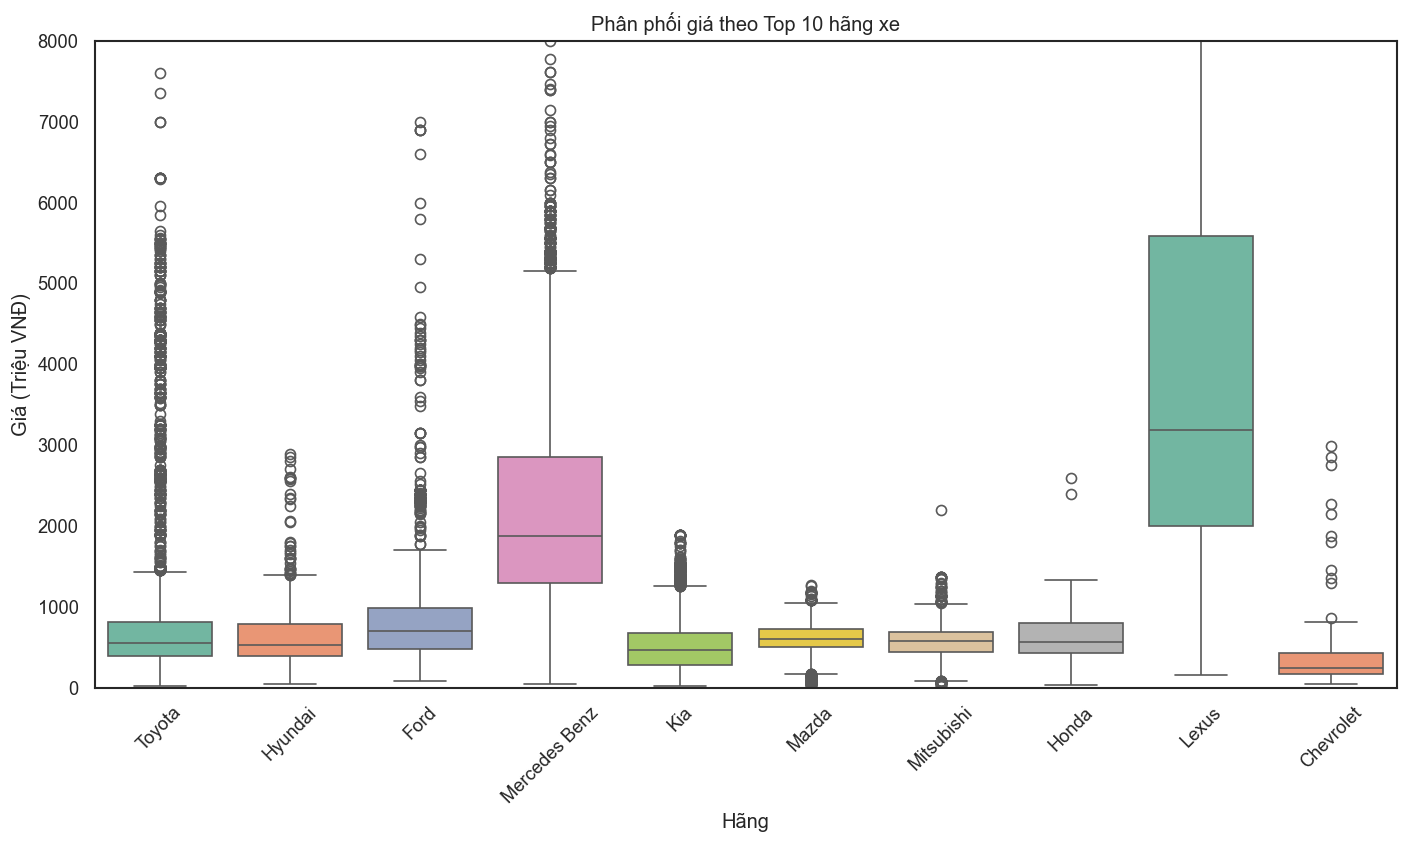

In [6]:
# 1. Price vs Manufacture Year (Depreciation Trend)
plt.figure(figsize=(12, 6))
# Calculate median price per year for a smoother trend line
median_price_per_year = df.groupby('Năm sản xuất')['Giá (triệu VND)'].median().reset_index()
# Filter years >= 2005 for a clearer trend
filtered_median = median_price_per_year[median_price_per_year['Năm sản xuất'] >= 2005]

sns.lineplot(data=filtered_median, x='Năm sản xuất', y='Giá (triệu VND)', marker='o', linewidth=2, color=PRIMARY_COLOR)
plt.title('Giá xe trung vị theo năm sản xuất (2005-2023)')
plt.xlabel('Năm sản xuất')
plt.ylabel('Giá trung vị (Triệu VNĐ)')
plt.grid(False)
plt.show()

# 2. Price Distribution by Top 10 Brands
plt.figure(figsize=(14, 7))
top_10_brands = df['Hãng'].value_counts().head(10).index
df_top_10 = df[df['Hãng'].isin(top_10_brands)]

sns.boxplot(data=df_top_10, x='Hãng', y='Giá (triệu VND)', order=top_10_brands, palette='Set2')
plt.title('Phân phối giá theo Top 10 hãng xe')
plt.ylabel('Giá (Triệu VNĐ)')
plt.ylim(0, 8000) # Cap at 8B for better visualization of boxes
plt.xticks(rotation=45)
plt.show()

**Nhận xét:**

- **Tương quan Năm sản xuất và Giá (Biểu đồ Line plot):** Giá xe trung vị có xu hướng tăng rõ rệt khi năm sản xuất càng gần hiện tại (giá trị xe cũ thấp hơn xe mới). Đường giá tăng dốc nhất ở giai đoạn 2017 đến 2021 (từ mức khoảng 540 triệu vọt lên đạt đỉnh 900 triệu VNĐ). Tuy nhiên, điểm kỳ lạ là đối với các xe sản xuất gần đây nhất (2022-2024), giá trung vị lại bị sụt giảm (chỉ dao động 780 - 890 triệu). Nguyên nhân có thể do cấu trúc tập dữ liệu: các xe siêu lướt (2022-2024) được rao bán phần lớn là xe cỡ nhỏ/phổ thông, trong khi đời 2021 tập trung nhiều mẫu xe sang giữ giá.

- **Phân khúc hãng xe (Biểu đồ Boxplot):** Chỉ ra Lexus và Mercedes Benz là các dòng xe sang với khoảng giá rộng và mức giá trung vị (median) cao vượt trội (từ 1.8 tỷ đến hơn 3.1 tỷ VNĐ) so với các dòng xe phổ thông như Toyota, Hyundai, Kia (có mức trung vị chỉ xoay quanh 465 - 550 triệu VNĐ).

<a id="42-categorical-relationships"></a>
### **4.2. Categorical Relationships**

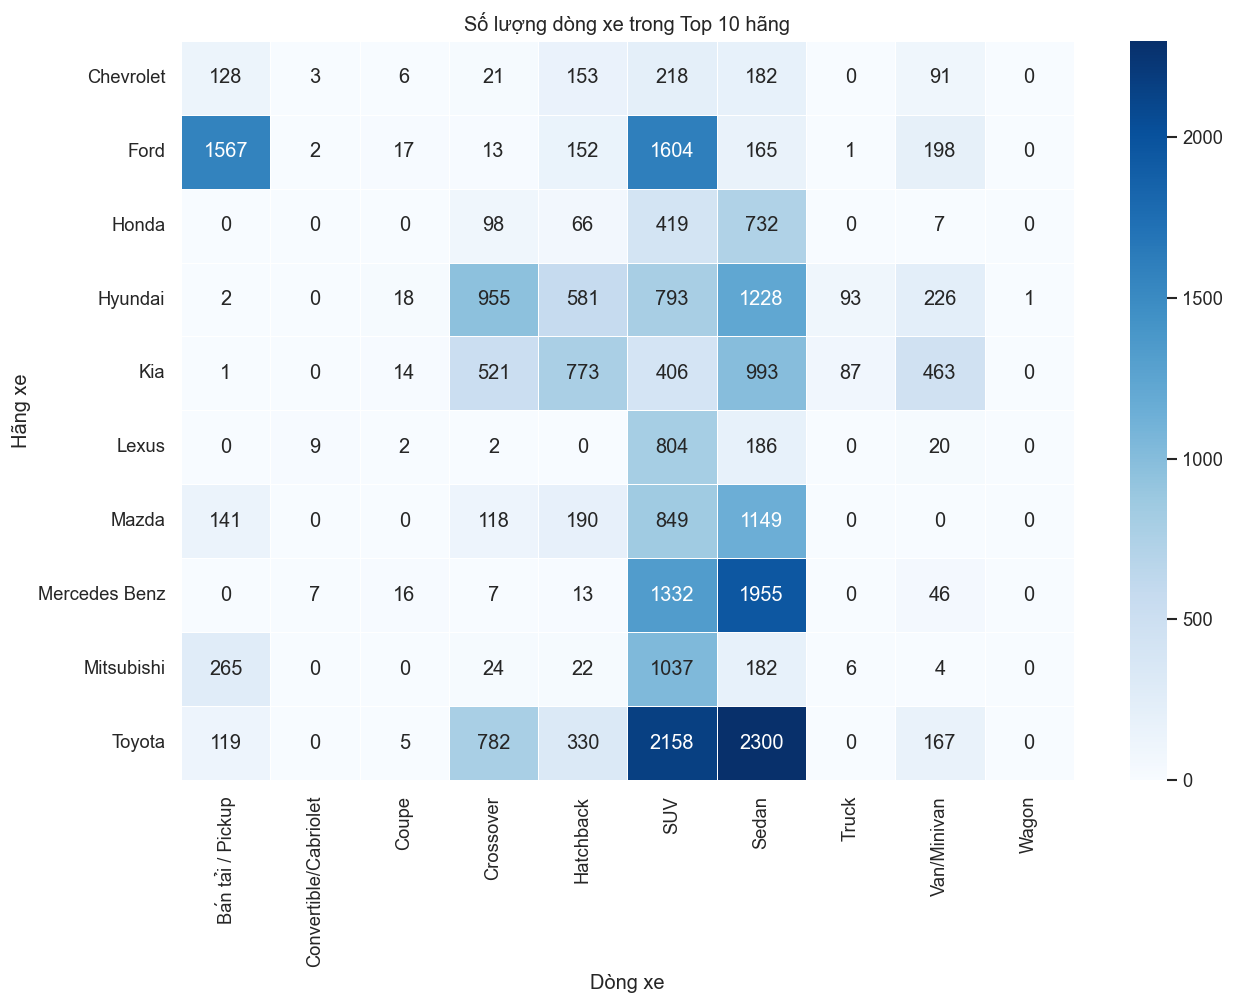

In [7]:
# Relationship between Brand and Body Type (Heatmap)
plt.figure(figsize=(12, 8))
# Crosstab of Top 10 Brands vs Body Types
brand_body_ct = pd.crosstab(df_top_10['Hãng'], df_top_10['Dòng xe'])

sns.heatmap(brand_body_ct, cmap='Blues', annot=True, fmt='d', linewidths=.5)
plt.title('Số lượng dòng xe trong Top 10 hãng')
plt.ylabel('Hãng xe')
plt.xlabel('Dòng xe')
plt.show()

**Nhận xét:**

Heatmap cho thấy định hướng sản phẩm của từng hãng. Ví dụ: Ford tập trung mạnh vào Bán tải (Pickup) và SUV, trong khi Toyota và Mazda phân bổ đều giữa SUV và Sedan.

<a id="43-correlation-matrix"></a>
### **4.3. Correlation Matrix**

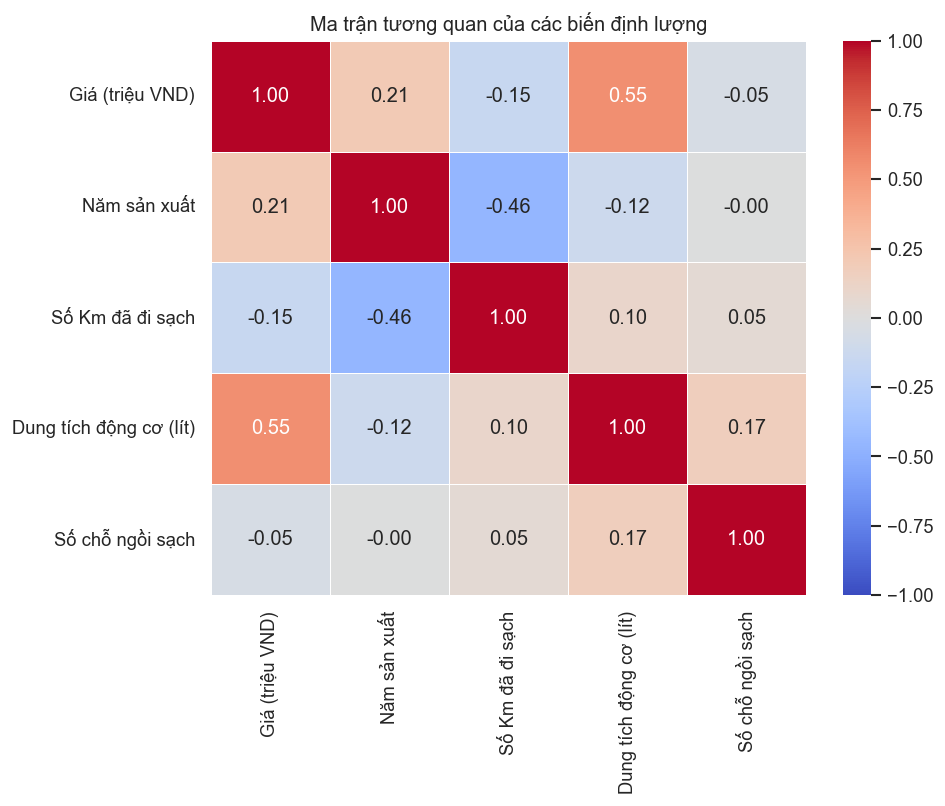

In [8]:
# Correlation matrix for continuous numerical variables
continuous_vars = ['Giá (triệu VND)', 'Năm sản xuất', 'Số Km đã đi sạch', 'Dung tích động cơ (lít)', 'Số chỗ ngồi sạch']
corr_matrix = df[continuous_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan của các biến định lượng')
plt.show()

**Nhận xét:**

- `Giá` và `Dung tích động cơ` có tương quan thuận mạnh nhất (hệ số +0.55): Động cơ càng lớn (thường là xe hạng sang/SUV lớn) sẽ có giá càng đắt.

- `Giá` và `Năm sản xuất` có tương quan thuận (hệ số +0.21): Năm sản xuất càng gần hiện tại (xe càng mới) thì giá càng cao.

- `Giá` và `Số Km` có tương quan nghịch (hệ số -0.15): Số Km đi càng nhiều, giá trị xe càng giảm.

<a id="5-advanced-analysis--insights"></a>
## **5. Advanced Analysis & Insights**

**Mục tiêu:** Đào sâu vào dữ liệu để tìm ra các cụm thị trường (segments) và điểm dữ liệu bất thường (outliers), chuẩn bị cho Machine Learning model.

<a id="51-market-segmentation"></a>
### **5.1. Market Segmentation (Clustering Concept)**

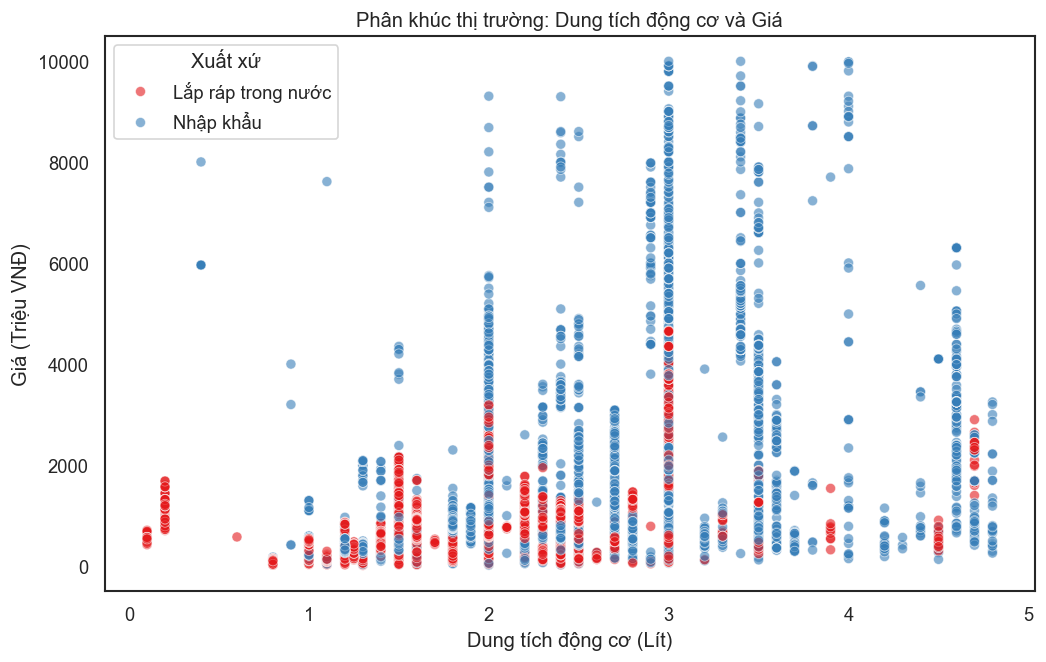

In [9]:
# Scatter plot to visualize potential clusters: Engine Capacity vs Price
plt.figure(figsize=(10, 6))
# Filter out extreme outliers for better clustering view
df_cluster_view = df[(df['Giá (triệu VND)'] < 10000) & (df['Dung tích động cơ (lít)'] < 5.0)]

sns.scatterplot(data=df_cluster_view, x='Dung tích động cơ (lít)', y='Giá (triệu VND)', hue='Xuất xứ', alpha=0.6, palette='Set1')
plt.title('Phân khúc thị trường: Dung tích động cơ và Giá')
plt.xlabel('Dung tích động cơ (Lít)')
plt.ylabel('Giá (Triệu VNĐ)')
plt.show()

**Nhận xét:**

Dữ liệu có xu hướng tụ thành các phân khúc dọc theo dung tích động cơ (như cụm 2.0L, cụm 1.5L). Đồng thời, ở cùng mức dung tích, xe nhập khẩu thường có trần giá cao hơn xe lắp ráp trong nước. Đây là yếu tố tốt cho K-Means.

<a id="52-anomaly-detection"></a>
### **5.2. Anomaly Detection (Outliers)**

Số lượng ngoại lai về giá (> 2080.0 triệu VNĐ): 4212
Top 5 xe ngoại lai đắt nhất:


,Hãng,Tên xe,Năm sản xuất,Giá (triệu VND)
5513,Ferrari,Xe Ferrari SF90 Stradale 4.0 V8 2020,2020.0,54000.0
3720,Rolls Royce,Xe Rolls Royce Cullinan Black Badge 2021,2021.0,46000.0
7081,Rolls Royce,Xe Rolls Royce Cullinan Black Badge 6.75 V12 2022,2022.0,45000.0
7049,Rolls Royce,Xe Rolls Royce Cullinan Black Badge 6.75 V12 2022,2022.0,45000.0
4474,Rolls Royce,Xe Rolls Royce Ghost Series II EWB 2021,2021.0,39999.0


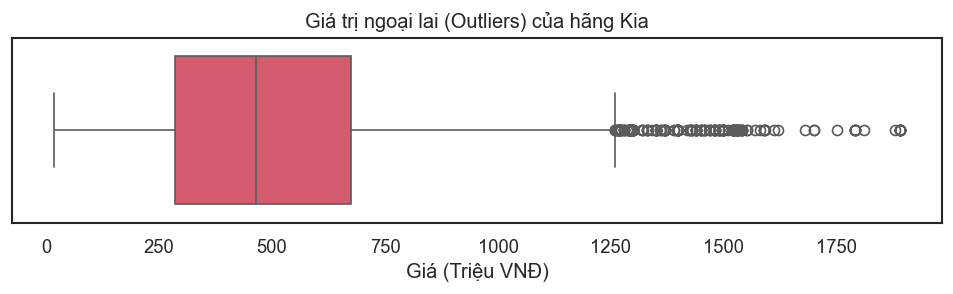

In [10]:
# Using IQR to find Price Outliers
Q1 = df['Giá (triệu VND)'].quantile(0.25)
Q3 = df['Giá (triệu VND)'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['Giá (triệu VND)'] > upper_bound]

print(f"Số lượng ngoại lai về giá (> {upper_bound:.1f} triệu VNĐ): {len(outliers)}")
print("Top 5 xe ngoại lai đắt nhất:")
display(outliers[['Hãng', 'Tên xe', 'Năm sản xuất', 'Giá (triệu VND)']].sort_values(by='Giá (triệu VND)', ascending=False).head())

# Visualizing outliers for a specific brand (e.g. Kia)
plt.figure(figsize=(10, 2))
sns.boxplot(x=df[df['Hãng'] == 'Kia']['Giá (triệu VND)'], color=ACCENT_COLOR)
plt.title('Giá trị ngoại lai (Outliers) của hãng Kia')
plt.xlabel('Giá (Triệu VNĐ)')
plt.show()

**Nhận xét:**

Phát hiện nhiều outlier về giá (những xe có giá lớn hơn ngưỡng Upper Bound là 2080 triệu VNĐ). Hầu hết outlier tổng thể thuộc về các dòng siêu xe (như Ferrari SF90 Stradale giá 54 tỷ, Rolls-Royce Cullinan giá 45-46 tỷ). Tuy nhiên, nếu xét nội bộ một hãng (ví dụ Kia), các outlier có thể là bản đặc biệt hoặc do lỗi người bán điền sai số 0.

<a id="6-key-findings--strategic-insights"></a>
## **6. Key Findings & Conclusion**

**Mục tiêu:** Tổng kết lại các Insights thu được từ quá trình EDA

### **Tổng kết các phát hiện quan trọng (Key Findings):**

1. **Thị hiếu & Phân khúc:** Thị trường xe hơi phân bổ cực kỳ mạnh vào các hãng phổ thông như Toyota, Hyundai, Ford và Kia. Về kiểu dáng, người tiêu dùng đặc biệt ưa chuộng dòng xe gầm cao (SUV) và xe 5 chỗ (Sedan), chiếm tỷ trọng áp đảo. Động cơ phổ biến nhất trên thị trường là các mẫu trang bị động cơ 2.0L và 1.5L.

2. **Định giá & Khấu hao:** Giá xe có phân phối lệch phải cực kỳ rõ rệt, đa số các giao dịch phổ biến đều nằm dưới mức 1,5 tỷ VNĐ. Biểu đồ giá trị theo năm sản xuất (Line plot) cho thấy đường giá trung vị dốc lên mạnh mẽ trong giai đoạn 2017-2021 (từ 540 triệu lên 900 triệu), nhưng lại có sự sụt giảm bất ngờ với các mẫu xe từ 2022-2024 (về lại mốc 780-890 triệu), phản ánh sự thay đổi về loại xe rao bán ở các năm gần nhất.

3. **Mối tương quan:** Qua ma trận tương quan, có 4 biến số tác động mạnh mẽ nhất đến giá xe bao gồm: *Năm sản xuất* (tương quan thuận - xe càng mới càng đắt), *Dung tích động cơ*, *Số Km đã đi* (tương quan nghịch - chạy càng nhiều càng rẻ), và *Thương hiệu (Brand)*. 

4. **Chất lượng dữ liệu & Ngoại lai:** Dữ liệu thô tồn tại các biến số nhiễu cần lọc kỹ trước khi train Machine Learning. Nổi bật là tập 4212 xe ngoại lai về giá chứa hàng loạt siêu xe (Rolls-Royce, Ferrari) đẩy trần giá lên mức 40-50 tỷ. Khoảng 1600 mẫu xe có năm sản xuất phi logic (như 2024, 2025 hoặc quá cũ) và xuất hiện một số tin đăng mâu thuẫn giữa tình trạng "Xe mới" nhưng số Km (ODO) lại rất lớn.